In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Set-up
# Get the parameters given lambda, volatility, number of steps, maturity and risk-free rate.
def GetTrinomialKRPara(lamb, sigma, N, T, r):
    dt = T / N
    u = np.exp(lamb * sigma * np.sqrt(dt))
    m = 1.
    d = np.exp(-lamb * sigma * np.sqrt(dt))
    qu = (1. / (2. * lamb ** 2)) + ((r - (sigma ** 2) / 2.) * np.sqrt(dt) / (2. * lamb * sigma))
    qm = 1. - (1. / lamb ** 2)
    qd = (1. / (2. * lamb ** 2)) - ((r - (sigma ** 2) / 2.) * np.sqrt(dt) / (2. * lamb * sigma))
    R = np.exp(r * dt)
    return u, m, d, qu, qm, qd, R

In [3]:
# Task 1: Parts (a) and (b)
# Create the trinomial tree.
def TrinomialTree(S0, u, qu, qm, qd, R, N, payoff):

    # Create an empty arrays to store the stock price and option value at each node
    V = np.zeros((2 * N + 1, N + 1))
    S = np.zeros((2 * N + 1, N + 1))

    # Set up S[p,n] = S0 * u^p for p = -n, -n+1, ..., n
    for n in range(N + 1):
      S[N - n:N + n + 1, n] = S0 * u**np.arange(n, -n - 1, -1)

    # Compute the option price at terminal time
    V[:,N] = payoff(S[:,N])

    # Loop backward in time
    for t in reversed(range(N)):
        V[N - t:N + t + 1, t] = (qu * V[N-t-1:N+t,t+1] + qm * V[N - t:N+t+1, t+1] + qd * V[N-t+1:N+t+2, t+1]) / R

    return V, S     # get the function to return the whole tree of stock prices and option values

def GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, payoff):
    V,S = TrinomialTree(S0, u, qu, qm, qd, R, N, payoff)
    return V[N,0]

# Black–Scholes European call option price
def BS_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

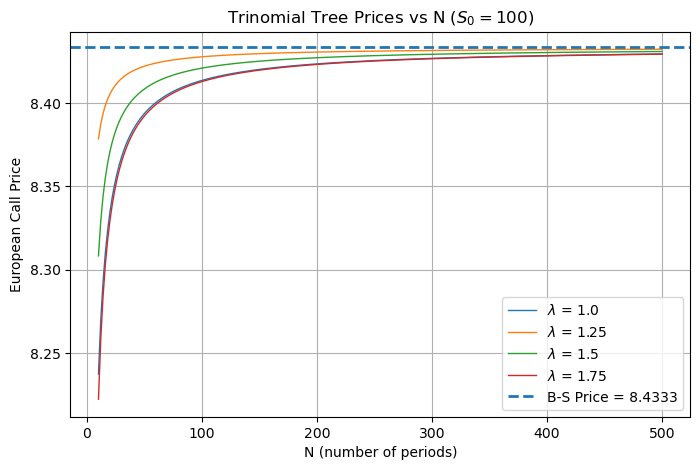

In [4]:
# Plot the fair price from trinomial tree model against the number of period N, with lambda varied.
sigma, T, r = 0.2, 1., 0.01
K, S0= 100., 100.

PutPayoff = lambda x : np.maximum(K - x, 0) # Payoff of a European put option.
CallPayoff = lambda x : np.maximum(x - K, 0) # Payoff of a European call option.

lambda_list = [1., 1.25, 1.5, 1.75]
N_list = list(range(10, 501, 2))

plt.figure(figsize=(8, 5))

for lam in lambda_list:
    prices = []
    for N in N_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        prices.append(price)

    plt.plot(N_list, prices, linewidth=1, label=rf"$\lambda$ = {lam}")

bs_price = BS_call_price(S0, K, r, sigma, T)
plt.axhline(bs_price, linestyle="--", linewidth=2, label=f"B-S Price = {bs_price:.4f}")

plt.xlabel("N (number of periods)")
plt.ylabel("European Call Price")
plt.title("Trinomial Tree Prices vs N ($S_0 = 100$)")
plt.legend()
plt.grid(True)
plt.savefig("Part(b).png", dpi=300, bbox_inches="tight")
plt.show()

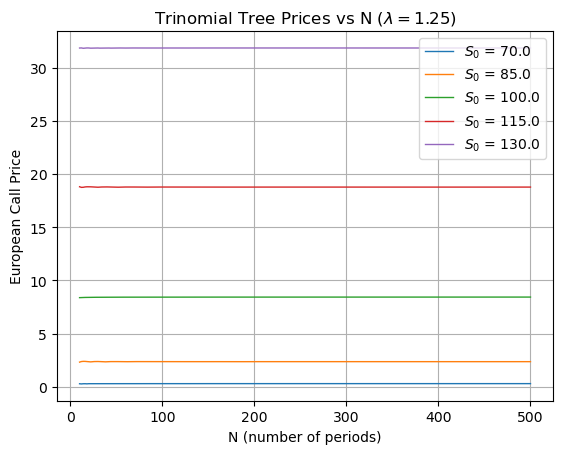

In [5]:
# Fix lambda, investigate the influence of the initial price S_0.
lam = 1.25
S0_list = np.linspace(70,130,5)
for S0 in S0_list:
    prices = []
    for N in N_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        prices.append(price)
    plt.plot(N_list, prices, linewidth=1, label=rf"$S_0$ = {S0}")

# bs_price = BS_call_price(S0, K, r, sigma, T)
# plt.axhline(bs_price, linestyle="--", linewidth=2, label=f"B-S Price = {bs_price:.4f}")

# Plot curves of different S_0 to see where our numerical solution converges to and when it converges.
plt.xlabel("N (number of periods)")
plt.ylabel("European Call Price")
plt.title(rf"Trinomial Tree Prices vs N ($\lambda = 1.25$)")
plt.legend()
plt.grid(True)
plt.savefig('Part(b)_2.png', dpi=300, bbox_inches="tight")
plt.show()

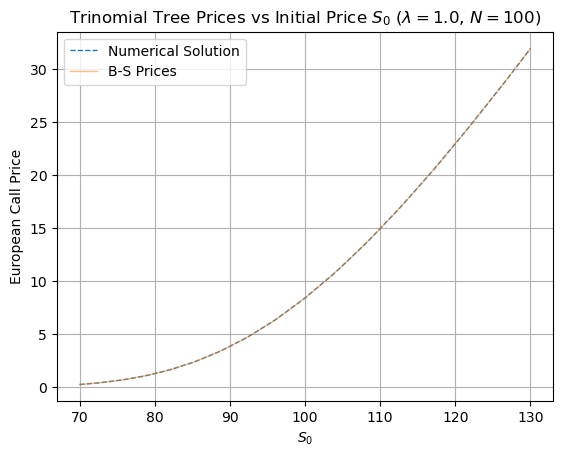

In [6]:
# Compare with the B-S price curve with different initial prices S_0.
lam, N = 1., 100
S0_list = np.linspace(70,130,121)
prices = []
bs_prices = []
for S0 in S0_list:
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
    price = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
    prices.append(price)
    bs_prices.append(BS_call_price(S0, K, r, sigma, T))
plt.plot(S0_list, prices, linewidth=1, alpha = 1, label = 'Numerical Solution', linestyle="--")
plt.plot(S0_list, bs_prices, linewidth = 1, alpha = 0.5, label = 'B-S Prices')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("European Call Price")
plt.title(rf"Trinomial Tree Prices vs Initial Price $S_0$ ($\lambda = {lam}$, $N = {N}$)")
plt.grid(True)
plt.savefig('Part(b)_3.png', dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Task 1: Part (c)
N, K = 500, 100
CallPayoff = lambda x : np.maximum(x - K, 0)

# Take 100 values for S_0
S0_list = np.linspace(70,130,100)
lambda_list = [1.0, 1.25, 1.5, 1.75]
rows = []
for S0 in S0_list:
    bs = BS_call_price(S0, K, r, sigma, T)
    for lam in lambda_list:
        u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)
        tri = GetEuroOptionPrice(S0, u, qu, qm, qd, R, N, CallPayoff)
        diff = tri - bs
        rows.append({
            "S0": float(S0),
            "lambda": lam,
            "Trinomial": float(tri),
            "BlackScholes": float(bs),
            "Diff (Tri - BS)": float(diff),
            "Abs Diff": float(abs(diff)),
        })

df = pd.DataFrame(rows)

pivot_diff = df.pivot(index="S0", columns="lambda", values="Diff (Tri - BS)")
pivot_abs  = df.pivot(index="S0", columns="lambda", values="Abs Diff")


In [8]:
pivot_abs.head()

lambda,1.00,1.25,1.50,1.75
S0,,,,
70.000000,0.001211,0.000595,0.000036,0.000038
70.606061,0.000078,0.000563,0.000619,0.000061
71.212121,0.001589,0.000257,0.000061,0.000280
71.818182,0.000023,0.000216,0.000007,0.000233
72.424242,0.001651,0.000553,0.000772,0.000456


In [9]:
# Conclude from the summary statistics that lambda = 1.25 is a suitable choice.
pivot_abs.describe()

lambda,1.00,1.25,1.50,1.75
count,100.000000,100.000000,100.000000,100.000000
mean,0.001508,0.000759,0.000886,0.001106
std,0.001127,0.000529,0.000572,0.000774
min,0.000023,0.000005,0.000002,0.000031
25%,0.000498,0.000344,0.000451,0.000544
50%,0.001327,0.000702,0.000831,0.000970
75%,0.002356,0.001101,0.001233,0.001522
max,0.003924,0.001885,0.002392,0.003491


In [10]:
# Task 2: Parts (a) and (b)
# Get the fair price of the American options. Only a minor change is applied on the recursive equation.
def AmericanTrinomialPrice(S0, sigma, T, r, N, lam, payoff):

    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lam, sigma, N, T, r)

    V = np.zeros((2 * N + 1, N + 1))
    S = np.zeros((2 * N + 1, N + 1))

    for n in range(N + 1):
        S[N - n:N + n + 1, n] = S0 * (u ** np.arange(n, -n - 1, -1))

    # Compute the option price at terminal time
    V[:,N] = payoff(S[:,N])
    # backward induction with early exercise
    for t in reversed(range(N)):
        hold_option = (qu * V[N-t-1:N+t,t+1] + qm * V[N - t:N+t+1, t+1] + qd * V[N-t+1:N+t+2, t+1]) / R

        # intrinsic value at time t
        exercise_option = payoff(S[N - t:N + t + 1, t])
        V[N - t:N + t + 1, t] = np.maximum(exercise_option, hold_option)

    return V  # time-0 value

def GetAmerOptionPrice(S0, sigma, T, r, N, lam, payoff):
    V = AmericanTrinomialPrice(S0, sigma, T, r, N, lam, payoff)
    return V[N,0]

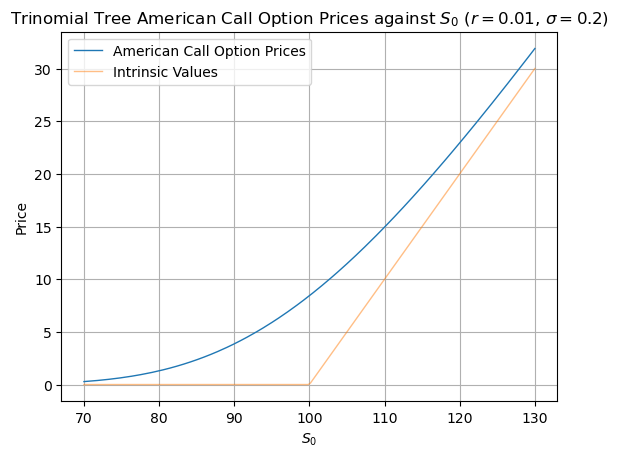

In [11]:
# Investigate the influence of interest rate r and volatility sigma.
lam, K, N = 1.25, 100, 500
sigma, T, r = 0.2, 1., 0.01

S0_list = np.linspace(70,130,200)
PutPayoff = lambda x : np.maximum(K - x, 0) # Payoff of put option.
CallPayoff = lambda x : np.maximum(x - K, 0) # Payoff of call option.

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, CallPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(S0, K) - K
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Call Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Call Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_b.png', dpi = 300, bbox_inches="tight")

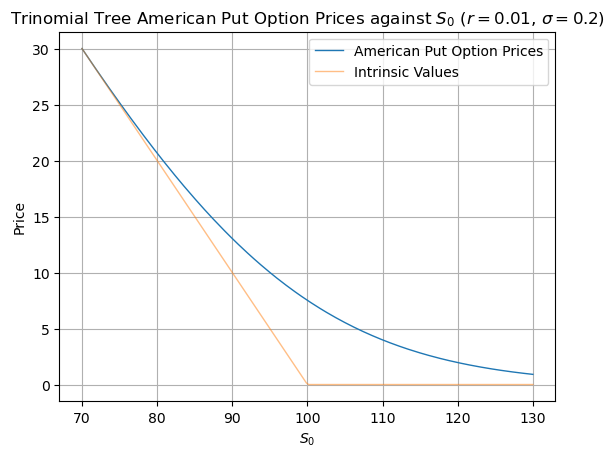

In [12]:
amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.2.png', dpi = 300, bbox_inches="tight")


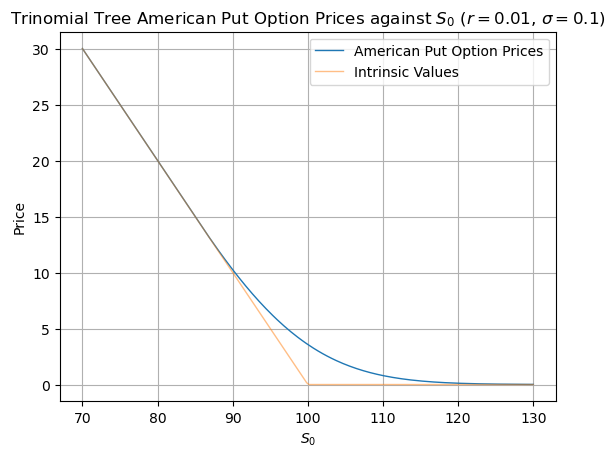

In [13]:
sigma = 0.1
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.1.png', dpi = 300, bbox_inches="tight")

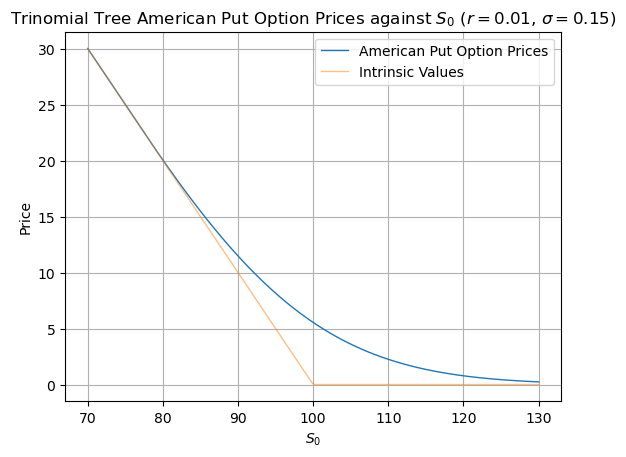

In [14]:
sigma = 0.15
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.15.png', dpi = 300, bbox_inches="tight")

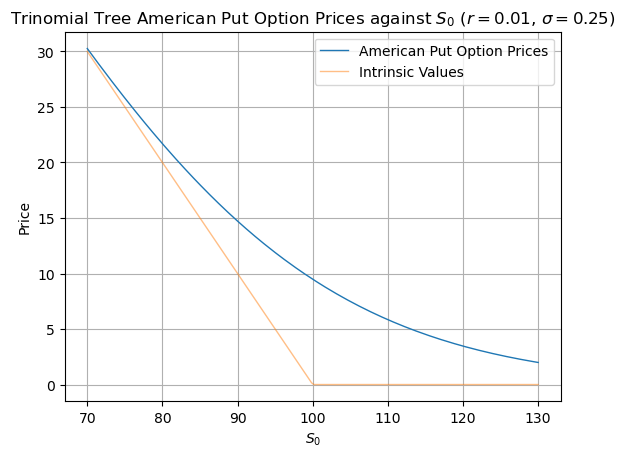

In [15]:
sigma = 0.25
r = 0.01

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.01_sigma_0.25.png', dpi = 300, bbox_inches="tight")

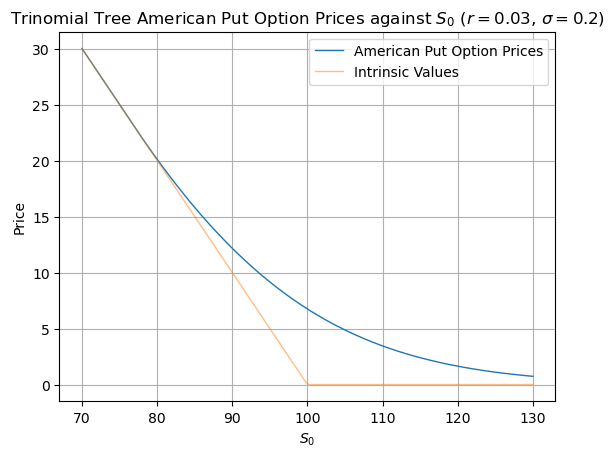

In [16]:
sigma = 0.2
r = 0.03

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.03_sigma_0.2.png', dpi = 300, bbox_inches="tight")

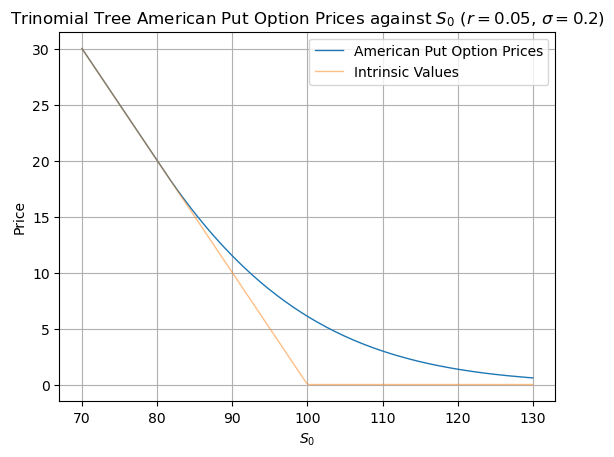

In [17]:
sigma = 0.2
r = 0.05

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.05_sigma_0.2.png', dpi = 300, bbox_inches="tight")

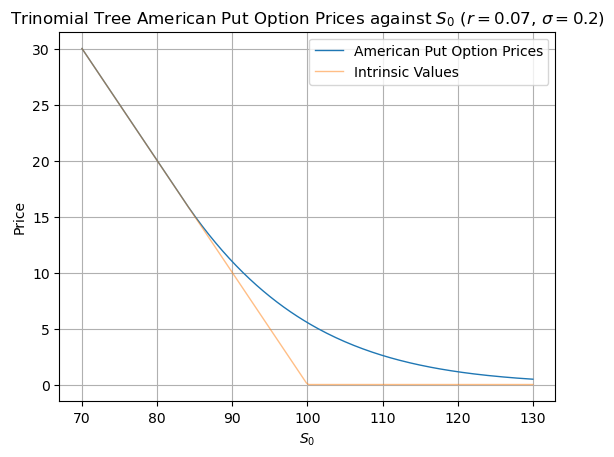

In [18]:
sigma = 0.2
r = 0.07

amer_prices, intrinsic_values = [], []
for S0 in S0_list:
    amer_price = GetAmerOptionPrice(S0, sigma, T, r, N, lam, PutPayoff)
    amer_prices.append(amer_price)
    intrinsic_value = np.maximum(K - S0, 0.)
    intrinsic_values.append(intrinsic_value)

plt.plot(S0_list, amer_prices, linewidth=1, alpha = 1, label = 'American Put Option Prices')
plt.plot(S0_list, intrinsic_values, linewidth = 1, alpha = 0.5, label = 'Intrinsic Values')

plt.legend()
plt.xlabel("$S_0$")
plt.ylabel("Price")
plt.title(rf"Trinomial Tree American Put Option Prices against $S_0$ ($r = {r}$, $\sigma = {sigma}$)")
plt.grid(True)
plt.savefig('Amer_part_c_r_0.07_sigma_0.2.png', dpi = 300, bbox_inches="tight")

In [19]:
# Task 3: Parts (a) and (b)
# Create the trinomial price tree.
def LookbackStockTree(S0, u, N):
    S = np.zeros((N + 1, 2 * N + 1))

    for n in range(N + 1):
        for k in range(-n, n + 1):
            S[n, k + N] = S0 * (u ** k)

    return S

# Get the fair price of the European lookback option.
def GetEuroLookbackPrice(S0, sigma, T, r, N, lamb):
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lamb, sigma, N, T, r)
    S = LookbackStockTree(S0, u, N)

    # V[n,k,j] := Fair option price at time n and state (s^n_k, m^n_j)
    V = np.zeros((N + 1, 2 * N + 1, N + 1))

    # Initialise boundary condition
    n = N
    for k in range(-N, N + 1):
        S_N_k = S[n, k + N]
        for j in range(max(0, k), N + 1):
            M_N_j = S0 * (u ** j)
            V[n, k + N, j] = M_N_j - S_N_k

    # Backward induction algorithm
    for n in reversed(range(N)):
        for k in range(-n, n + 1):
            for j in range(max(0, k), n + 1):
                j_up = max(j, k + 1)
                j_mid = j
                j_down = j

                value = (
                    qu * V[n + 1, (k + 1) + N, j_up]
                    + qm * V[n + 1, k + N, j_mid]
                    + qd * V[n + 1, (k - 1) + N, j_down]
                ) / R

                V[n, k + N, j] = value

    return V[0, N, 0]

# Get the fair price of the American lookback option.
def GetAmerLookbackPrice(S0, sigma, T, r, N, lamb):
    u, m, d, qu, qm, qd, R = GetTrinomialKRPara(lamb, sigma, N, T, r)
    S = LookbackStockTree(S0, u, N)

    # V[n,k,j] := Fair option price at time n and state (s^n_k, m^n_j)
    V = np.zeros((N + 1, 2 * N + 1, N + 1))

    # Iintialise boundary condition
    n = N
    for k in range(-N, N + 1):
        S_N_k = S[n, k + N]
        for j in range(max(0, k), N + 1):
            M_N_j = S0 * (u ** j)
            V[n, k + N, j] = M_N_j - S_N_k

    # Backward induction algorithm
    for n in reversed(range(N)):
        for k in range(-n, n + 1):
            S_n_k = S[n, k + N]
            for j in range(max(0, k), n + 1):
                j_up = max(j, k + 1)
                j_mid = j
                j_down = j

                value = (
                    qu * V[n + 1, (k + 1) + N, j_up]
                    + qm * V[n + 1, k + N, j_mid]
                    + qd * V[n + 1, (k - 1) + N, j_down]
                ) / R
                M_n_j = S0 * (u ** j)
                exer = M_n_j - S_n_k
                V[n, k + N, j] = max(exer, value)

    return V[0, N, 0]

In [20]:
import time
# Create a table of the prices of American and European lookback option, as well as the time required to calculate, with N varied.
def LookbackPriceTable(S0, sigma, T, r, lamb, N_list):
    results = []

    for N in N_list:
        # European
        t0 = time.perf_counter()
        euro_price = GetEuroLookbackPrice(S0, sigma, T, r, N, lamb)
        t1 = time.perf_counter()

        # American
        amer_price = GetAmerLookbackPrice(S0, sigma, T, r, N, lamb)
        t2 = time.perf_counter()

        results.append({
            "N": N,
            "European Price": euro_price,
            "European Time (s)": t1 - t0,
            "American Price": amer_price,
            "American Time (s)": t2 - t1
        })

    return pd.DataFrame(results)

In [21]:
S0 = 100
sigma = 0.2
T = 1.0
r = 0.01
lamb = 1.25

N_list = np.arange(20,301,20)

df = LookbackPriceTable(S0, sigma, T, r, lamb, N_list)
print(df)

      N  European Price  European Time (s)  American Price  American Time (s)
0    20       13.485118           0.009701       13.630139           0.007672
1    40       14.274746           0.044348       14.414394           0.060573
2    60       14.641836           0.152231       14.779423           0.187713
3    80       14.865814           0.379555       15.002458           0.451973
4   100       15.020894           0.677645       15.156875           0.880427
5   120       15.136537           1.258139       15.272062           1.496165
6   140       15.227102           1.718452       15.362279           2.440305
7   160       15.300544           2.657328       15.435479           3.318385
8   180       15.361675           3.693053       15.496424           4.757008
9   200       15.413601           5.281057       15.548200           6.709963
10  220       15.458430           6.896771       15.592895           8.973284
11  240       15.497648           8.910100       15.631999      

In [22]:
N_list_2 = np.arange(320,500,20)

df_2 = LookbackPriceTable(S0, sigma, T, r, lamb, N_list_2)
print(df_2)

     N  European Price  European Time (s)  American Price  American Time (s)
0  320       15.616474          22.540527       15.750530          26.654211
1  340       15.639522          26.931437       15.773530          34.835165
2  360       15.660654          32.188028       15.794618          38.425390
3  380       15.680123          36.634147       15.814049          55.529009
4  400       15.698136          50.849036       15.832030          63.463443
5  420       15.714867          58.193424       15.848731          69.819034
6  440       15.730462          57.850126       15.864300          73.186187
7  460       15.745043          65.857368       15.878857          83.648389
8  480       15.758716          76.563370       15.892511          90.251263


In [23]:
import numpy as np
import scipy.stats as si
from scipy.sparse import diags
from scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

In [24]:
### Question 2, Part 1, Fine Difference Schemes for Local Volatility PDE
# Explicit finite difference scheme for local volatility PDE in tau-form:
def explicit_fd_localvol(
    T: float,
    r: float,
    S_min: float,
    S_max: float,
    N: int,
    M: int,
    g,                 # payoff function g(s)
    sigma_tau,         # local vol in tau-form: sigma_tau(tau, s)
    l,                 # left boundary: l(tau)
    u,                 # right boundary: u(tau)
    return_surface: bool = False,
):
    
    # grid setup
    dtau = T / N
    ds = (S_max - S_min) / M
    tau_grid = np.linspace(0.0, T, N + 1)
    s_grid = np.linspace(S_min, S_max, M + 1)

    # initial condition at tau=0
    V = g(s_grid).astype(float)
    V[0] = l(tau_grid[0])
    V[-1] = u(tau_grid[0])

    if return_surface:
        surface = np.empty((N + 1, M + 1), dtype=float)
        surface[0, :] = V

    # precompute b(s)=r*s and c=r on grid (b depends only on s here)
    b_grid = r * s_grid
    c_val = r

    # time-stepping loop
    for n in range(N):
        tau_n = tau_grid[n]
        tau_np1 = tau_grid[n + 1]

        # evaluate sigma_tau on interior points only
        s_int = s_grid[1:-1]                       # k=1,...,M-1
        sigma_int = sigma_tau(tau_n, s_int)        # vectorized preferred
        a_int = 0.5 * (sigma_int ** 2) * (s_int ** 2)

        b_int = b_grid[1:-1]                       # r*s_k for interior
        # c_int is constant = r

        # build A,B,C for interior indices k=1,...,M-1
        A = (dtau / ds**2) * a_int - (dtau / (2.0 * ds)) * b_int
        B = -(2.0 * dtau / ds**2) * a_int - dtau * c_val
        C = (dtau / ds**2) * a_int + (dtau / (2.0 * ds)) * b_int

        # matrix form: V_tilde = (I + L^n) V
        # we can apply the tri-diagonal operator without building a full matrix.
        V_tilde = V.copy()

        # interior update: k=1..M-1
        V_tilde[1:-1] = (
            A * V[0:-2] + (1.0 + B) * V[1:-1] + C * V[2:]
        )

        # overwrite boundaries at tau_{n+1}
        V_tilde[0] = l(tau_np1)
        V_tilde[-1] = u(tau_np1)

        V = V_tilde

        if return_surface:
            surface[n + 1, :] = V

    if return_surface:
        return tau_grid, s_grid, V, surface
    return tau_grid, s_grid, V

# Interpolation on increasing grid
def linear_interp(x_grid: np.ndarray, y: np.ndarray, x: float) -> float:
    if x <= x_grid[0]:
        return float(y[0])
    if x >= x_grid[-1]:
        return float(y[-1])

    j = np.searchsorted(x_grid, x) - 1
    x0, x1 = x_grid[j], x_grid[j + 1]
    y0, y1 = y[j], y[j + 1]
    w = (x - x0) / (x1 - x0)
    return float((1 - w) * y0 + w * y1)

In [25]:
# Local Volatility in tau-form: sigma(T - tau, s)
def sigma_tau(tau, s, T=1):
    t = T - tau
    return (1 + t/30.0) * (0.1 + 0.4*np.exp(-s/50.0))

# Payoff function for a call option: g(s) = max(s-K, 0)
def payoff_call(s, K=100.0):
    return np.maximum(s - K, 0.0)

# Left and right boundaries for a call option
def l_call(tau):
    return 0.0

def u_call(tau, S_max=300.0, K=100.0, r=0.01):
    return S_max - K*np.exp(-r*tau)

In [26]:
# Market and option parameters
K, r, T = 100, 0.01, 1
# Grid parameters
S_min, S_max = 10, 300
N, M = 2000, 400

In [27]:
# Run the explicit finite difference scheme for local vol PDE
tau_grid, s_grid, V_final = explicit_fd_localvol(
    T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
    g=lambda s: payoff_call(s, K=K),
    sigma_tau=lambda tau, s: sigma_tau(tau, s, T=T),
    l=l_call,
    u=lambda tau: u_call(tau, S_max=S_max, K=K, r=r),
)

In [28]:
# Generate option prices for S0 in [80, 120] with step 5
S0_list = np.arange(80, 125, 5)
prices = np.array([linear_interp(s_grid, V_final, S0) for S0 in S0_list])

print("S0:", S0_list)
print("Prices:", prices)

S0: [ 80  85  90  95 100 105 110 115 120]
Prices: [ 0.75209842  1.47686885  2.64796391  4.37670161  6.7303367   9.71483954
 13.27620426 17.31541596 21.7156225 ]


In [29]:
# Tridiagional matrix solver. a, b, c are the low, mid and high diagional of the matrix
# d is the constant vector on the RHS
# (copied shamelessly from https://gist.github.com/cbellei/8ab3ab8551b8dfc8b081c518ccd9ada9)
def TDMAsolver(a, b, c, d):

    nf = len(d) # number of equations
    ac, bc, cc, dc = map(np.array, (a, b, c, d)) # copy arrays
    for it in range(1, nf):
        mc = ac[it-1]/bc[it-1]
        bc[it] = bc[it] - mc*cc[it-1]
        dc[it] = dc[it] - mc*dc[it-1]

    xc = bc
    xc[-1] = dc[-1]/bc[-1]

    for il in range(nf-2, -1, -1):
        xc[il] = (dc[il]-cc[il]*xc[il+1])/bc[il]

    return xc

In [30]:
# Implicit finite difference scheme for local vol PDE in tau-form:
def implicit_fd_localvol(
    T, r, S_min, S_max, N, M,
    g,                  # payoff function g(s)
    sigma_tau_func,     # sigma_tau(tau, s) vectorized
    l_func, u_func,     # boundary functions l(tau), u(tau)
    return_surface=False
):
    # grid setup
    dtau = T / N
    ds = (S_max - S_min) / M
    tau_grid = np.linspace(0.0, T, N + 1)
    s_grid = np.linspace(S_min, S_max, M + 1)

    # initial condition at tau=0
    V = g(s_grid).astype(float)
    V[0] = l_func(tau_grid[0])
    V[-1] = u_func(tau_grid[0])

    # to store the full surface if requested
    surface = None
    if return_surface:
        surface = np.empty((N + 1, M + 1), dtype=float)
        surface[0, :] = V

    # precompute b(s)=r*s and c=r on grid
    b_grid = r * s_grid
    c_val = r

    # time loop: n = 1..N
    for n in range(1, N + 1):
        tau_n = tau_grid[n]

        # boundary values at this time level
        V_left = float(l_func(tau_n))
        V_right = float(u_func(tau_n))

        # interior grid points k=1..M-1 (length M-1)
        s_int = s_grid[1:-1]
        b_int = b_grid[1:-1]

        sigma_int = sigma_tau_func(tau_n, s_int)
        a_int = 0.5 * (sigma_int**2) * (s_int**2)

        # A,B,C at time level n
        A = (dtau / ds**2) * a_int - (dtau / (2.0 * ds)) * b_int
        B = -(2.0 * dtau / ds**2) * a_int - dtau * c_val
        C = (dtau / ds**2) * a_int + (dtau / (2.0 * ds)) * b_int

        # build tridiagonal system for interior unknowns:
        # (I - L^n) V_int^n = RHS
        #
        # diag:  (1 - B_k^n) for k=1..M-1      length M-1
        # lower: (-A_k^n)    for k=2..M-1      length M-2
        # upper: (-C_k^n)    for k=1..M-2      length M-2
        diag = (1.0 - B).astype(float)    # length M-1
        lower = (-A[1:]).astype(float)    # length M-2
        upper = (-C[:-1]).astype(float)   # length M-2

        # RHS is previous time level interior
        rhs = V[1:-1].astype(float).copy()

        # boundary contributions:
        # first interior equation (k=1): includes -A_1^n * V_0^n  -> move to RHS: +A_1^n * V_0^n
        # last  interior equation (k=M-1): includes -C_{M-1}^n * V_M^n -> move to RHS: +C_{M-1}^n * V_M^n
        rhs[0]  += A[0]  * V_left
        rhs[-1] += C[-1] * V_right

        # solve tridiagonal system with TDMA
        V_int = TDMAsolver(lower, diag, upper, rhs)

        # assemble full vector at time level n
        V_new = V.copy()
        V_new[0] = V_left
        V_new[-1] = V_right
        V_new[1:-1] = V_int

        V = V_new
        if return_surface:
            surface[n, :] = V

    if return_surface:
        return tau_grid, s_grid, V, surface
    return tau_grid, s_grid, V

In [31]:
# Run the implicit finite difference scheme for local vol PDE
tau_grid, s_grid, V_final = implicit_fd_localvol(
    T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
    g=lambda s: np.maximum(s-K, 0.0),
    sigma_tau_func=lambda tau, s: sigma_tau(tau, s, T=T),
    l_func=l_call,
    u_func=lambda tau: u_call(tau, S_max=S_max, K=K, r=r),
)

In [32]:
# Generate option prices for S0 in [80, 120] with step 5
S0_list = np.arange(80, 125, 5)
prices = np.array([linear_interp(s_grid, V_final, S0) for S0 in S0_list])

print("S0:", S0_list)
print("Prices:", prices)

S0: [ 80  85  90  95 100 105 110 115 120]
Prices: [ 0.75234967  1.47683218  2.64754426  4.37595034  6.72944366  9.71404391
 13.27568362 17.31522233 21.71569374]


In [33]:
# Crank–Nicolson finite difference scheme for local volatility PDE in tau-form:
def crank_nicolson_fd_localvol(
    T, r, S_min, S_max, N, M,
    g,                  # payoff function g(s)
    sigma_tau_func,     # sigma_tau(tau, s) vectorized
    l_func, u_func,     # boundary functions l(tau), u(tau)
    return_surface=False
):
    # grid setup
    dtau = T / N
    ds = (S_max - S_min) / M
    tau_grid = np.linspace(0.0, T, N + 1)
    s_grid = np.linspace(S_min, S_max, M + 1)

    # initial condition at tau=0
    V_prev = g(s_grid).astype(float)
    V_prev[0] = float(l_func(tau_grid[0]))
    V_prev[-1] = float(u_func(tau_grid[0]))

    # to store the full surface if requested
    surface = None
    if return_surface:
        surface = np.empty((N + 1, M + 1), dtype=float)
        surface[0, :] = V_prev

    # precompute b(s)=r*s and c=r on grid
    b_grid = r * s_grid
    c_val = r

    # Helper to compute A,B,C at a given time level n (for interior points)
    def compute_ABC(tau_n):
        s_int = s_grid[1:-1]           # k=1..M-1
        b_int = b_grid[1:-1]           # r*s_k
        sigma_int = sigma_tau_func(tau_n, s_int)
        a_int = 0.5 * (sigma_int**2) * (s_int**2)

        A = (dtau / ds**2) * a_int - (dtau / (2.0*ds)) * b_int
        B = -(2.0 * dtau / ds**2) * a_int - dtau * c_val
        C = (dtau / ds**2) * a_int + (dtau / (2.0*ds)) * b_int
        return A, B, C

    # time loop: n = 1..N
    for n in range(1, N + 1):
        tau_nm1 = tau_grid[n - 1]
        tau_n = tau_grid[n]

        # boundary values at new time level n
        V_left_n = float(l_func(tau_n))
        V_right_n = float(u_func(tau_n))

        # coefficients at n-1 and n
        A_nm1, B_nm1, C_nm1 = compute_ABC(tau_nm1)
        A_n,   B_n,   C_n   = compute_ABC(tau_n)

        # RHS: d = (I + 0.5 L^{n-1}) V^{n-1} on interior
        # Compute (L^{n-1} V^{n-1})_k for k=1..M-1
        LV_nm1_int = (
            A_nm1 * V_prev[0:-2] +
            B_nm1 * V_prev[1:-1] +
            C_nm1 * V_prev[2:]
        )
        rhs = V_prev[1:-1] + 0.5 * LV_nm1_int   # length M-1

        # LHS system: (I - 0.5 L^n) V^n = RHS
        # Interior tridiagonal:
        # diag:  1 - 0.5 B_k^n
        # lower: -0.5 A_k^n  for k=2..M-1  (length M-2)
        # upper: -0.5 C_k^n  for k=1..M-2  (length M-2)
        diag = (1.0 - 0.5 * B_n).astype(float)      # length M-1
        lower = (-0.5 * A_n[1:]).astype(float)      # length M-2
        upper = (-0.5 * C_n[:-1]).astype(float)     # length M-2

        # Boundary contributions from LHS moved to RHS:
        # first interior equation includes -0.5 A_1^n * V_0^n  -> add +0.5 A_1^n V_0^n
        # last  interior equation includes -0.5 C_{M-1}^n * V_M^n -> add +0.5 C_{M-1}^n V_M^n
        rhs[0]  += 0.5 * A_n[0]  * V_left_n
        rhs[-1] += 0.5 * C_n[-1] * V_right_n

        # solve for interior V^n
        V_int = TDMAsolver(lower, diag, upper, rhs)

        # assemble full solution at time n and overwrite boundaries
        V_new = V_prev.copy()
        V_new[0] = V_left_n
        V_new[-1] = V_right_n
        V_new[1:-1] = V_int

        V_prev = V_new
        if return_surface:
            surface[n, :] = V_prev

    if return_surface:
        return tau_grid, s_grid, V_prev, surface
    return tau_grid, s_grid, V_prev

In [34]:
# Run the Crank–Nicolson finite difference scheme for local vol PDE
tau_grid, s_grid, V_final = crank_nicolson_fd_localvol(
    T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
    g=lambda s: np.maximum(s - K, 0.0),
    sigma_tau_func=lambda tau, s: sigma_tau(tau, s, T=T),
    l_func=l_call,
    u_func=lambda tau: u_call(tau, S_max=S_max, K=K, r=r),
)

In [35]:
# Generate option prices for S0 in [80, 120] with step 5
S0_list = np.arange(80, 125, 5)
prices = np.array([linear_interp(s_grid, V_final, S0) for S0 in S0_list])

print("S0:", S0_list)
print("Prices:", prices)

S0: [ 80  85  90  95 100 105 110 115 120]
Prices: [ 0.75222401  1.47685045  2.64775404  4.37632599  6.72989022  9.71444174
 13.2759439  17.31531908 21.71565807]


In [36]:
from scipy.stats import norm
from scipy.optimize import brentq

### Question 2, Part 2: Implied Volatility
# Black–Scholes formula for European call option price
def bs_call_price(S0, K, r, T, sigma):
    if sigma <= 0:
        return max(S0 - K*np.exp(-r*T), 0.0)
    
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K*np.exp(-r*T) * norm.cdf(d2)

# Function to compute implied volatility using Brent's method
def implied_volatility(S0, K, r, T, C_market,
                       sigma_lower=1e-6,
                       sigma_upper=5.0):

    def objective(sigma):
        return bs_call_price(S0, K, r, T, sigma) - C_market

    return brentq(objective, sigma_lower, sigma_upper)

In [37]:
import matplotlib.pyplot as plt

# Fixed parameters
S0 = 100.0
r = 0.01
T = 1.0
S_min, S_max = 10.0, 300.0

# Smaller grid to speed up the smile plot
N, M = 1000, 300

# Strike grid
K_list = np.arange(70, 131, 1)

In [38]:
# Boundary conditions and payoff for call with variable strike K
def payoff_call_K(s, K):
    return np.maximum(s - K, 0.0)

def u_call_K(tau, K, S_max=S_max, r=r):
    # Call boundary at s=S_max: V ≈ S_max - K e^{-r tau}
    return S_max - K*np.exp(-r*tau)

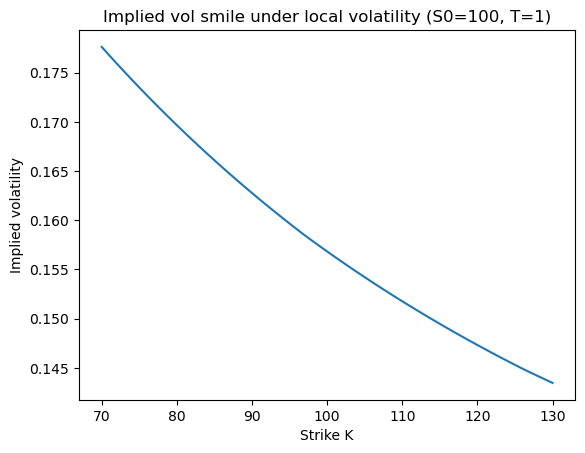

In [39]:
# Initialize lists to store prices and implied volatilities 
prices_lv = []
iv_lv = []

# Run the Crank–Nicolson scheme for each strike and compute implied volatility
for K in K_list:
    tau_grid, s_grid, V_final = crank_nicolson_fd_localvol(
        T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
        g=lambda s, K=K: payoff_call_K(s, K),
        sigma_tau_func=lambda tau, s: sigma_tau(tau, s, T=T),  # your local vol
        l_func=l_call,
        u_func=lambda tau, K=K: u_call_K(tau, K),
    )

    C = linear_interp(s_grid, V_final, S0)
    prices_lv.append(C)

    # implied vol from BS
    iv = implied_volatility(S0, K, r, T, C)
    iv_lv.append(iv)

# Convert to numpy arrays for plotting
prices_lv = np.array(prices_lv)
iv_lv = np.array(iv_lv)

# Plot the implied volatility against strike to visualize the smile
plt.figure()
plt.plot(K_list, iv_lv)
plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Implied vol smile under local volatility (S0=100, T=1)")
plt.show()

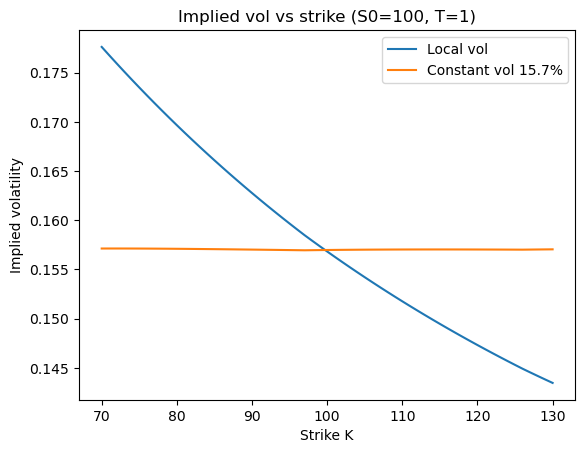

In [40]:
# Constant volatility for comparison
sigma_const = 0.157  # 15.7%
def sigma_tau_const(tau, s):
    return sigma_const + 0.0*s  # vector-safe

# Initialize lists to store prices and implied volatilities for constant vol case
prices_const = []
iv_const = []

# Run the Crank–Nicolson scheme for each strike and compute implied volatility for constant vol case
for K in K_list:
    tau_grid, s_grid, V_final = crank_nicolson_fd_localvol(
        T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
        g=lambda s, K=K: payoff_call_K(s, K),
        sigma_tau_func=lambda tau, s: sigma_tau_const(tau, s),
        l_func=l_call,
        u_func=lambda tau, K=K: u_call_K(tau, K),
    )

    C = linear_interp(s_grid, V_final, S0)
    prices_const.append(C)

    iv = implied_volatility(S0, K, r, T, C)
    iv_const.append(iv)

# Convert to numpy arrays for plotting
iv_const = np.array(iv_const)

# Plot the implied volatility against strike to compare local vol and constant vol
plt.figure()
plt.plot(K_list, iv_lv, label="Local vol")
plt.plot(K_list, iv_const, label="Constant vol 15.7%")
plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Implied vol vs strike (S0=100, T=1)")
plt.legend()
plt.show()

In [41]:
### Question 2, Part 3: Down-and-in basic put option
# Payoff function for a put option: g(s) = max(K-s, 0)
def payoff_put(s, K=K):
    return np.maximum(K - s, 0.0)

# Boundary conditions for a put option
def u_put(tau):
    return 0.0

def l_put(tau, K=K, r=r, S_min=S_min):
    return K * np.exp(-r * tau) - S_min

In [42]:
# Price a put option using Crank–Nicolson scheme with local vol PDE
def price_put_CN(s0, K, T, r, S_min, S_max, N, M, sigma_tau_func, l_func, u_func):
    tau_grid, s_grid, V_final = crank_nicolson_fd_localvol(
        T=T, r=r, S_min=S_min, S_max=S_max, N=N, M=M,
        g=lambda s: payoff_put(s, K),
        sigma_tau_func=sigma_tau_func,
        l_func=l_func,
        u_func=u_func,
    )
    return linear_interp(s_grid, V_final, s0)

# Price down-and-in barrier put via parity: P_di = P_eur - P_do
def price_down_and_in_put_via_parity(s0, K, B, T, r, S_min_eur, S_max, N, M, sigma_tau_func):
    # European put on [S_min_eur, S_max]
    P_eur = price_put_CN(
        s0, K, T, r,
        S_min=S_min_eur, S_max=S_max, N=N, M=M,
        sigma_tau_func=sigma_tau_func,
        l_func=lambda tau: l_put(tau, K=K, r=r, S_min=S_min_eur),
        u_func=lambda tau: u_put(tau),
    )

    # Down-and-out put on [B, S_max], KO boundary at B
    P_do = price_put_CN(
        s0, K, T, r,
        S_min=B, S_max=S_max, N=N, M=M,
        sigma_tau_func=sigma_tau_func,
        l_func=lambda tau: 0.0,   # V(τ,B)=0
        u_func=lambda tau: 0.0,   # put at S_max ~ 0
    )

    # Down-and-in by parity
    P_di = P_eur - P_do
    return P_di, P_eur, P_do

In [43]:
import pandas as pd

# Fixed parameters
S0 = 100.0
K  = 100.0
T  = 1.0
r  = 0.01

# Barrier set
B_list = [60.0, 70.0, 80.0, 90.0]

# Grid parameters
N, M = 1000, 300

# Domain truncation
S_max = 300.0
S_min_eur = 10.0   # for European put solve

In [44]:
rows = []
for B in B_list:
    # Local vol
    P_di_lv, P_eur_lv, P_do_lv = price_down_and_in_put_via_parity(
        S0, K, B, T, r, S_min_eur, S_max, N, M,
        sigma_tau_func=lambda tau, s: sigma_tau(tau, s, T=T)
    )

    # Constant vol
    P_di_c, P_eur_c, P_do_c = price_down_and_in_put_via_parity(
        S0, K, B, T, r, S_min_eur, S_max, N, M,
        sigma_tau_func=lambda tau, s: sigma_tau_const(tau, s)
    )

    # Percentage difference between local vol and constant vol prices
    pct_diff = (P_di_lv - P_di_c) / P_di_c * 100.0 if P_di_c != 0 else np.nan

    # Store results in a list of dicts for DataFrame
    rows.append({
        "B_in": B,
        "P_DI_localvol": float(P_di_lv),
        "P_DI_constvol": float(P_di_c),
        "%diff (LV-const)/const": float(pct_diff),
        # optional diagnostics:
        "P_Eur_LV": float(P_eur_lv),
        "P_DO_LV": float(P_do_lv),
        "P_Eur_const": float(P_eur_c),
        "P_DO_const": float(P_do_c),
    })

# Create DataFrame and display results
df = pd.DataFrame(rows).sort_values("B_in")
pd.set_option("display.precision", 6)
df

,B_in,P_DI_localvol,P_DI_constvol,%diff (LV-const)/const,P_Eur_LV,P_DO_LV,P_Eur_const,P_DO_const
0,60.0,0.231456,0.049627,366.389543,5.734186,5.502730,5.740167,5.690540
1,70.0,1.229887,0.709020,73.463024,5.734186,4.504300,5.740167,5.031148
2,80.0,3.510522,3.106083,13.020883,5.734186,2.223664,5.740167,2.634084
3,90.0,5.461833,5.431253,0.563045,5.734186,0.272353,5.740167,0.308914
